# 모델 구현 (루브릭1)

In [1]:
import torch
import torch.nn as nn

### BasicBlock

##### BasicBlock 구조 파악

![basic_block](./basicblock.png)

##### BasicBlock 구현

In [2]:
# basic block은 conv layer 2개로 구성
class BasicBlock(nn.Module):
    expansion = 1 # conv layer의 채널 수를 조정할 때 곱해주는 값
    def __init__(self, in_channels, setted_channels, use_shortcut, stride=1):
        '''
        in_channels: 맨 처음 block이 사용하는 필터의 채널 수(직전 output의 채널)        
        setted_channels: block 내부에서 사용되는 필터의 채널 수
        '''
        super().__init__()
        self.use_shortcut = use_shortcut
        
        # 첫번째 conv는 이미지 사이즈 유지하거나(stride=1,pad=1), 절반으로 줄이거나(stride=2)        
        self.conv1 = nn.Conv2d(in_channels, setted_channels, kernel_size=3, stride=stride, padding=1, bias=False) 
        self.bn1 = nn.BatchNorm2d(setted_channels)
        self.relu = nn.ReLU(inplace=True) # 메모리 아끼기 위해
        # 두번째 conv는 이미지 사이즈를 유지(stride=1,pad=1)
        self.conv2 = nn.Conv2d(setted_channels, setted_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(setted_channels)              
        
        # shortcut 사용 시, block의 결과 F(x).shape == 입력 x.shape 같아야 더할 수 있음
        
        # shape이 일치하는 case -> 빈 Sequential()에 x만 들어가서 F(x)에 더해주면 됨
        self.shortcut = nn.Sequential() 

        # shape 일치하지 않은 case
        # 1. stage2부터 stage가 바뀌면서 이미지 사이즈를 줄여야 해서 stride=2로 부여
        # 2. 직전 block output: x의 채널(현재 in_channels)과 이번 block output: F(x)의 채널(expansion*setted_channel)이 다를 때
        # x -> 채널: 현재 block 마지막 채널(expansion*setted_channel), 사이즈: 절반(stride=2)으로
        if stride != 1 or in_channels != self.expansion*setted_channels:
            self.shortcut = nn.Sequential(                
                nn.Conv2d(in_channels, self.expansion*setted_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*setted_channels)
            )

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.bn1(residual)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        residual = self.bn2(residual)
        if self.use_shortcut:
            residual += self.shortcut(x)
        residual = self.relu(residual)
        return residual           
        

### BottleneckBlock

##### BottleneckBlock 구조 파악

![BottleneckBlock](./bottleneckblock.png)

##### BottleneckBlock 구현

In [3]:
# Bottlenek block은 conv layer 3개로 구성
class BottleneckBlock(nn.Module):
    expansion = 4 # conv layer의 채널 수를 조정할 때 곱해주는 값
    def __init__(self, in_channels, setted_channels, use_shortcut, stride=1):
        '''
        in_channels: 맨 처음 block이 사용하는 필터의 채널 수(직전 output의 채널)
        setted_channels: block 내부에서 사용되는 필터의 채널 수        
        '''
        super().__init__()
        self.use_shortcut = use_shortcut

        # 첫번째 conv(1x1)는 이미지 사이즈 유지함(= stride 필요 없음)
        self.conv1 = nn.Conv2d(in_channels, setted_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(setted_channels)

        # 사이즈 줄일 때, 두번째 conv에서 줄임(stride=2) 그래야 정보 보존하면서 사이즈 감소
        self.conv2 = nn.Conv2d(setted_channels, setted_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(setted_channels)
        
        # 세번째 conv에서 채널 수 4배로 확장(exansion)
        self.conv3 = nn.Conv2d(setted_channels, self.expansion*setted_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion*setted_channels)

        self.relu = nn.ReLU(inplace=True)

        # shortcut 사용 시, block의 결과 F(x).shape == 입력 x.shape 같아야 더할 수 있음
        
        # shape이 일치하는 case -> 빈 Sequential()에 x만 들어가서 F(x)에 더해주면 됨
        self.shortcut = nn.Sequential()
        
        # shape 일치하지 않은 case
        # 1. stage2부터 stage가 바뀌면서 이미지 사이즈를 줄여야 해서 stride=2로 부여
        # 2. 직전 block output: x의 채널(현재 in_channels)과 이번 block output: F(x)의 채널(expansion*setted_channel)이 다를 때
        # x -> 채널: 현재 block 마지막 채널(expansion*setted_channel), 사이즈: 절반(stride=2)으로  
        if stride != 1 or in_channels != self.expansion*setted_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion*setted_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*setted_channels)
            )

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.bn1(residual)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        residual = self.bn2(residual)
        residual = self.relu(residual)
        residual = self.conv3(residual)
        residual = self.bn3(residual)
        if self.use_shortcut:
            residual += self.shortcut(x)
        residual = self.relu(residual)
        return residual
        

### ResNet

In [4]:
class ResNet(nn.Module):
    def __init__(self, block, block_num_list, use_shortcut, num_classes):
        '''
        block: BasicBlock or BottleneckBlock
        block_num_list: 각 stage에서 사용할 block의 개수가 담긴 list
        use_shortcut: shortcut 사용하지 않는 plain 모델 사용 여부
        num_classes: 모델로 분류하려고 하는 데이터의 클래스 수
        '''
        super().__init__()

        self.init_channels = 64 # block을 통과하기 직전 output의 채널 수
        
        self.stem = nn.Sequential(            
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False), 
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.stage1 = self._make_stage(block, 64, block_num_list[0], use_shortcut, stride=1)
        self.stage2 = self._make_stage(block, 128, block_num_list[1], use_shortcut, stride=2)
        self.stage3 = self._make_stage(block, 256, block_num_list[2], use_shortcut, stride=2)
        self.stage4 = self._make_stage(block, 512, block_num_list[3], use_shortcut, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(0.5)
        
        # avgpool 적용하면 각 채널 별로 값이 1개만 남음 -> 마지막 블록의 채널 수 만큼 input node
        self.fc = nn.Linear(512*block.expansion, num_classes)

    def _make_stage(self, block, setted_channels, num_block, use_shortcut, stride):
        '''
        setted_channels: 각 block의 필터의 채널 개수로 지정한 값(64,128,256,512)
        num_block: stage를 구성하는 block 개수
        stride: 사이즈 줄일 때 stride=2 사용
        '''
        layers = []
        # stage의 첫번째 block
        layers.append(block(self.init_channels, setted_channels, use_shortcut, stride))
        # 첫 블록의 첫번째 layer는 이전 블록의 output 채널이 in_channel로 들어가야 함
        # 첫번째 block 만들고 self.init_channels을 블록의 마지막 채널 개수로 업데이트
        
        self.init_channels = block.expansion*setted_channels 
        
        # stage의 두번째 block부터 마지막 block            
        for _ in range(num_block-1): # 위에서 하나 만들었으니까 num_block-1개 생성
            # 새로 시작하는 블록은 이전 블록의 output 채널(위에서 업데이트 된 self.init_channels)을 in_channel로 맞춤
            layers.append(block(self.init_channels, setted_channels, use_shortcut, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        x = self.dropout(x)
        x = torch.flatten(x, start_dim = 1) # fc layer 통과해야 해서 flatten        
        x = self.fc(x)
        return x           
            

In [5]:
# 모델을 생성해주는 함수
def build_resnet(version_num, resnet_configs, use_shortcut=False, num_classes=1000):
    '''
    version_num: resnet 버전(18, 34, 50, 101, 152)
    resnet_configs: 각 버전의 stage를 구성하는 block 개수를 담고 있는 configuration 딕셔너리
    use_shortcut: plain모델 사용할지 여부(dafault: False -> shorcut 사용)
    num_classes: 최종 분류하려는 데이터의 클래스 개수(데이터에 따라 달라짐)
    '''
    available_versions = resnet_configs.keys()
    assert version_num in available_versions, "ResNet 버전을 확인하세요."

    if version_num in [18, 34]:        
        if use_shortcut:
            model = ResNet(BasicBlock, resnet_configs[version_num], use_shortcut, num_classes)
            print(f"모델: ResNet{version_num}, block 개수: {resnet_configs[version_num]}, 출력 데이터 클래스 수: {num_classes}")
        else:
            model = ResNet(BasicBlock, resnet_configs[version_num], use_shortcut, num_classes)
            print(f"모델: ResNet{version_num}_plain, block 개수: {resnet_configs[version_num]}, 출력 데이터 클래스 수: {num_classes}")            
        
    else:
        if use_shortcut:
            model = ResNet(BottleneckBlock, resnet_configs[version_num], use_shortcut, num_classes)
            print(f"모델: ResNet{version_num}, block 개수: {resnet_configs[version_num]}, 출력 데이터 클래스 수: {num_classes}")
        else:
            model = ResNet(BottleneckBlock, resnet_configs[version_num], use_shortcut, num_classes)
            print(f"모델: ResNet{version_num}_plain, block 개수: {resnet_configs[version_num]}, 출력 데이터 클래스 수: {num_classes}")        
        
    return model

# 모델 구조 비교 (루브릭1)

In [6]:
from torchinfo import summary

### 구현 모델

In [7]:
resnet_configs = {
    18: [2,2,2,2],
    34: [3,4,6,3],
    50: [3,4,6,3],
    101: [3,4,23,3],
    152: [3,8,36,3],
}

In [8]:
use_shortcut = True
NUM_CLASSES = 1000

##### ResNet34

In [9]:
# 모델 생성 함수 build_resnet()으로 모델 생성
resnet34_ex = build_resnet(34, resnet_configs, use_shortcut, NUM_CLASSES)

모델: ResNet34, block 개수: [3, 4, 6, 3], 출력 데이터 클래스 수: 1000


In [10]:
# output이 잘 나오는지 output의 shape 출력
print(resnet34_ex(torch.randn(1,3,224,224)).shape)

torch.Size([1, 1000])


In [11]:
# 구조 비교를 위해 학습 파라미터 수 계산
num_params = [torch.numel(p) for p in resnet34_ex.parameters() if p.requires_grad]
print(f"파라미터 수: {sum(num_params)}")    

파라미터 수: 21797672


In [12]:
summary(resnet34_ex)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       9,408
│    └─BatchNorm2d: 2-2                  128
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
├─Sequential: 1-2                        --
│    └─BasicBlock: 2-5                   --
│    │    └─Conv2d: 3-1                  36,864
│    │    └─BatchNorm2d: 3-2             128
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  36,864
│    │    └─BatchNorm2d: 3-5             128
│    │    └─Sequential: 3-6              --
│    └─BasicBlock: 2-6                   --
│    │    └─Conv2d: 3-7                  36,864
│    │    └─BatchNorm2d: 3-8             128
│    │    └─ReLU: 3-9                    --
│    │    └─Conv2d: 3-10                 36,864
│    │    └─BatchNorm2d: 3-11            128
│    │    └─Sequential: 3-12             --
│  

##### ResNet50

In [13]:
# 모델 생성 함수 build_resnet()으로 모델 생성
resnet50_ex = build_resnet(50, resnet_configs, use_shortcut, NUM_CLASSES)

모델: ResNet50, block 개수: [3, 4, 6, 3], 출력 데이터 클래스 수: 1000


In [14]:
# output이 잘 나오는지 output의 shape 출력
print(resnet50_ex(torch.randn(1,3,224,224)).shape)

torch.Size([1, 1000])


In [15]:
# 구조 비교를 위해 학습 파라미터 수 계산
num_params = [torch.numel(p) for p in resnet50_ex.parameters() if p.requires_grad]
print(f"파라미터 수: {sum(num_params)}")  

파라미터 수: 25557032


In [16]:
summary(resnet50_ex)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       9,408
│    └─BatchNorm2d: 2-2                  128
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
├─Sequential: 1-2                        --
│    └─BottleneckBlock: 2-5              --
│    │    └─Conv2d: 3-1                  4,096
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    │    └─Conv2d: 3-5                  16,384
│    │    └─BatchNorm2d: 3-6             512
│    │    └─ReLU: 3-7                    --
│    │    └─Sequential: 3-8              16,896
│    └─BottleneckBlock: 2-6              --
│    │    └─Conv2d: 3-9                  16,384
│    │    └─BatchNorm2d: 3-10            128
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12           

### torchvision 모델

In [17]:
from torchinfo import summary
import torchvision

In [18]:
torchvision_resnet34 = torchvision.models.resnet34(pretrained=True)
torchvision_resnet50 = torchvision.models.resnet50(pretrained=True)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weig

In [19]:
torchvision_resnet34_params = [torch.numel(p) for p in torchvision_resnet34.parameters() if p.requires_grad]
print(f"torchvision resnet34 파라미터 수: {sum(torchvision_resnet34_params)}")

torchvision resnet34 파라미터 수: 21797672


In [20]:
summary(torchvision_resnet34)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─BasicBlock: 2-1                   --
│    │    └─Conv2d: 3-1                  36,864
│    │    └─BatchNorm2d: 3-2             128
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  36,864
│    │    └─BatchNorm2d: 3-5             128
│    └─BasicBlock: 2-2                   --
│    │    └─Conv2d: 3-6                  36,864
│    │    └─BatchNorm2d: 3-7             128
│    │    └─ReLU: 3-8                    --
│    │    └─Conv2d: 3-9                  36,864
│    │    └─BatchNorm2d: 3-10            128
│    └─BasicBlock: 2-3                   --
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12            12

In [21]:
torchvision_resnet50_params = [torch.numel(p) for p in torchvision_resnet50.parameters() if p.requires_grad]
print(f"torchvision resnet50 파라미터 수: {sum(torchvision_resnet50_params)}")

torchvision resnet50 파라미터 수: 25557032


In [22]:
summary(torchvision_resnet50)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─Bottleneck: 2-1                   --
│    │    └─Conv2d: 3-1                  4,096
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    │    └─Conv2d: 3-5                  16,384
│    │    └─BatchNorm2d: 3-6             512
│    │    └─ReLU: 3-7                    --
│    │    └─Sequential: 3-8              16,896
│    └─Bottleneck: 2-2                   --
│    │    └─Conv2d: 3-9                  16,384
│    │    └─BatchNorm2d: 3-10            128
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12            128
│    │    └─Conv2d: 3-13               

# 모델 학습 및 ablation study (루브릭 2, 3)

### 하이퍼 파라미터 설정

In [23]:
BATCH_SIZE = 64
EPOCH = 10
LR = 0.005

### 이미지 데이터 준비

In [24]:
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader

In [25]:
DATA_PATH = "./data"

##### 원본 크기 확인

In [26]:
# # 원본 크기 확인
# raw_dataset = OxfordIIITPet(root=DATA_PATH, split="trainval", download=True)

# min_width = float('inf')
# min_height = float('inf')
# min_dims = None

# print("데이터셋 크기 전수 조사 중...")
# for img, _ in raw_dataset:
#     w, h = img.size # PIL Image 객체의 size는 (width, height)를 반환
    
#     if w < min_width:
#         min_width = w
#     if h < min_height:
#         min_height = h
        
#     # 가로*세로 면적이 가장 작은 이미지를 추적하고 싶다면:
#     if min_dims is None or (w * h < min_dims[0] * min_dims[1]):
#         min_dims = (w, h)

# print(f"\n[결과]")
# print(f"가장 작은 가로 길이: {min_width}px")
# print(f"가장 작은 세로 길이: {min_height}px")
# print(f"면적이 가장 작은 이미지의 해상도: {min_dims[0]}x{min_dims[1]}")

##### 데이터 전처리

In [27]:
# 이미지 사이즈가 제각각이라 224x224로 Resize하고, tensor로 변환, 이미지넷 데이터 통계값으로 normalize
transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC), # 좀더 선명한 보간법
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [28]:
trainset = OxfordIIITPet(root=DATA_PATH, split="trainval", target_types="category", transform=transform, download=True)
testset = OxfordIIITPet(root=DATA_PATH, split="test", target_types="category", transform=transform, download=True)

In [29]:
# print(trainset.__getitem__(0))

In [30]:
len(trainset) / BATCH_SIZE

57.5

In [31]:
print(f"image shape: {trainset.__getitem__(0)[0].shape}")
print(f"image shape: {trainset.__getitem__(1000)[0].shape}")
print(f"tain 데이터 개수: {len(trainset)}")
print(f"class 종류: {len(trainset.classes)}") 
print(f"class 예시 5가지: {trainset.classes[:5]}")


image shape: torch.Size([3, 224, 224])
image shape: torch.Size([3, 224, 224])
tain 데이터 개수: 3680
class 종류: 37
class 예시 5가지: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


In [32]:
trainloader = DataLoader(dataset=trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(dataset=testset, batch_size=BATCH_SIZE, shuffle=False)

##### 데이터 시각화

In [33]:
# 이미지 시각화를 위해 차원 순서를 변경하고 denormalize
def trans_for_imshow(img):    
    mean = np.array([0.485, 0.456, 0.406])
    std= np.array([0.229, 0.224, 0.225])
    img = img.numpy()    
    img = np.transpose(img, (1,2,0))
    img = img*std+mean
    img = np.clip(img, 0, 1) # 픽셀값이 0~1사이 값만 갖도록 제한
    return img

In [34]:
# 이미시 예시 시각화 
def show_images(dataset, n_imgs=4):
    imgs, labels = next(iter(dataset))
    fig, axes = plt.subplots(2,2, figsize=(6,6))
    axes = axes.flatten()

    for i in range(n_imgs):
        ax = axes[i]
        img = trans_for_imshow(imgs[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

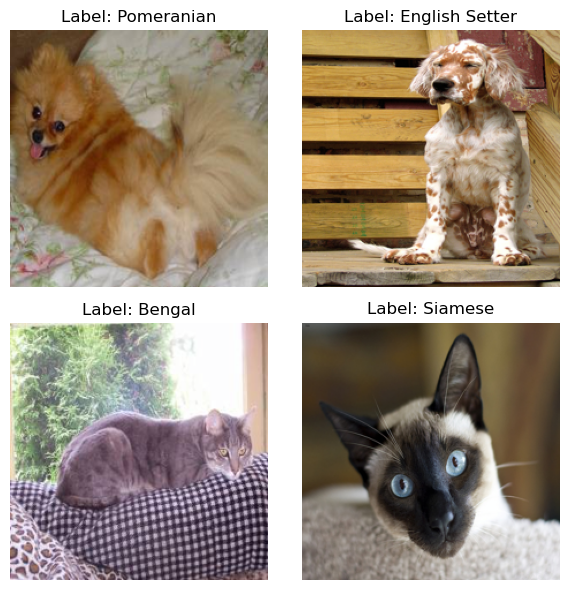

In [35]:
show_images(trainloader)

### 모델 학습

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [38]:
# triain, validation 함수 (1 epoch이 끝날 때마다 validation)
def train_val(model, trainloader, testloader, criterion, optimizer, res_dict):
    res_dict['train_loss'] = []
    res_dict['val_acc'] = []

    for epoch in range(EPOCH):        
        model.train()
        running_loss = 0.
        correct = 0
        total = 0
        
        for batch_idx, (inputs, labels) in enumerate(trainloader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() # running_loss는 배치의 평균 loss가 배치 개수만큼 누적            
            # running_loss += loss.item()*len(labels) # 배치 전체의 loss 누적 
            total += len(labels)
            _, pred = torch.max(outputs, dim=1)
            correct += (pred==labels).sum().item()
            
            # 여기서는 특정 배치까지 도달할 때의 평균 loss를 출력해서 전체 누적 사용 안 함
            if batch_idx % 50 == 49:                
                # print(f"배치 내 데이터 수: {len(labels)}")
                print(f"[Epoch: {epoch+1}, {batch_idx+1:4d}th batch] loss: {running_loss/(batch_idx+1):.3f}")

        train_loss = running_loss / len(trainloader) # 배치별 평균 loss 누적한 걸 배치 개수로 나누는 방법
        # train_loss = running_loss / len(trainloader.dataset) # 전체 데이터 loss 누적하고 전체 데이터 수로 나누는 방법
        train_acc = correct / total # len(trainloader.dataset) == total
        res_dict['train_loss'].append(train_loss)

        print(f"Epoch {epoch+1}, Train Accuracy: {train_acc*100:.2f}%")

        # epoch 한 번 끝나고 validation(test)
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, pred = torch.max(outputs, dim = 1)
                total += len(labels)
                correct += (pred==labels).sum().item()

            val_acc = correct / total
            res_dict['val_acc'].append(val_acc)

            print(f"Epoch {epoch+1}, Validation Accuracy: {val_acc*100:.2f}%")
    
    print("training is finished...")

    return res_dict

In [39]:
# train loss를 시각화해주는 함
def plot_train_loss(resnet_loss, resnet_plaing_loss, model_name):
    '''
    resnet_loss: resnet 모델의 train loss를 담고 있는 list
    resnet_plaing_loss: resnet_plain 모델의 train loss를 담고 있는 list
    model_name: 모델 이름
    '''
    
    plt.plot(resnet_loss, 'r', label=f"{model_name} Training Loss")
    plt.plot(resnet_plaing_loss, 'b', label=f"{model_name}_plain Training Loss")
    
    plt.title(f'{model_name} Training Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.savefig(f'{model_name}_train_loss.png')
    plt.show()

In [40]:
# validation accuracy를 시각화해주는 함
def plot_val_acc(resnet_loss, resnet_plaing_loss, model_name):
    '''
    resnet_loss: resnet 모델의 validation accuracy를 담고 있는 list
    resnet_plaing_loss: resnet_plain 모델의 validation accuracy를 담고 있는 list
    model_name: 모델 이름
    '''
    
    plt.plot(resnet_loss, 'r', label=f"{model_name} Validation Accuracy")
    plt.plot(resnet_plaing_loss, 'b', label=f"{model_name}_plain Validation Accuracy")
    
    plt.title(f'{model_name} Validation Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.savefig(f'{model_name}_val_acc.png')
    plt.show()

#### ResNet34

##### ResNet34 with shortcut

In [41]:
# 결과 비교를 위한 성능 저장할 딕셔너리
resnet34_results = {'train_loss': [], 'val_acc': []}  

In [42]:
VERSION_NUM = 34 # resnet version
use_shortcut = True # shortcut 사용할건지 
NUM_CLASSES = 37 # 분류하려는 문제의 class 수

In [43]:
resnet34 = build_resnet(VERSION_NUM, resnet_configs, use_shortcut, NUM_CLASSES).to(device)

모델: ResNet34, block 개수: [3, 4, 6, 3], 출력 데이터 클래스 수: 37


In [44]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet34.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)

In [45]:
resnet34_results = train_val(resnet34, trainloader, testloader, criterion, optimizer, resnet34_results)

[Epoch: 1,   50th batch] loss: 3.827
Epoch 1, Train Accuracy: 4.27%
Epoch 1, Validation Accuracy: 4.55%
[Epoch: 2,   50th batch] loss: 3.646
Epoch 2, Train Accuracy: 6.25%
Epoch 2, Validation Accuracy: 6.51%
[Epoch: 3,   50th batch] loss: 3.391
Epoch 3, Train Accuracy: 9.10%
Epoch 3, Validation Accuracy: 10.08%
[Epoch: 4,   50th batch] loss: 3.247
Epoch 4, Train Accuracy: 12.80%
Epoch 4, Validation Accuracy: 10.98%
[Epoch: 5,   50th batch] loss: 3.107
Epoch 5, Train Accuracy: 14.84%
Epoch 5, Validation Accuracy: 13.68%
[Epoch: 6,   50th batch] loss: 2.948
Epoch 6, Train Accuracy: 16.98%
Epoch 6, Validation Accuracy: 11.80%
[Epoch: 7,   50th batch] loss: 2.780
Epoch 7, Train Accuracy: 21.20%
Epoch 7, Validation Accuracy: 13.57%
[Epoch: 8,   50th batch] loss: 2.641
Epoch 8, Train Accuracy: 23.56%
Epoch 8, Validation Accuracy: 19.54%
[Epoch: 9,   50th batch] loss: 2.507
Epoch 9, Train Accuracy: 27.93%
Epoch 9, Validation Accuracy: 18.89%
[Epoch: 10,   50th batch] loss: 2.286
Epoch 10, Tra

##### ResNet34_plain (without shortcut)

In [46]:
# 결과 비교를 위한 성능 저장할 딕셔너리
resnet34_plain_results = {'train_loss': [], 'val_acc': []}  

In [47]:
VERSION_NUM = 34 # resnet version
use_shortcut = False # shortcut 사용할건지 
NUM_CLASSES = 37 # 분류하려는 문제의 class 수

In [48]:
resnet34_plain = build_resnet(VERSION_NUM, resnet_configs, use_shortcut, NUM_CLASSES).to(device)

모델: ResNet34_plain, block 개수: [3, 4, 6, 3], 출력 데이터 클래스 수: 37


In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet34_plain.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)

In [50]:
resnet34_plain_results = train_val(resnet34_plain, trainloader, testloader, criterion, optimizer, resnet34_plain_results)

[Epoch: 1,   50th batch] loss: 3.673
Epoch 1, Train Accuracy: 2.80%
Epoch 1, Validation Accuracy: 2.97%
[Epoch: 2,   50th batch] loss: 3.638
Epoch 2, Train Accuracy: 3.12%
Epoch 2, Validation Accuracy: 3.43%
[Epoch: 3,   50th batch] loss: 3.578
Epoch 3, Train Accuracy: 4.32%
Epoch 3, Validation Accuracy: 4.55%
[Epoch: 4,   50th batch] loss: 3.486
Epoch 4, Train Accuracy: 5.90%
Epoch 4, Validation Accuracy: 5.83%
[Epoch: 5,   50th batch] loss: 3.424
Epoch 5, Train Accuracy: 6.68%
Epoch 5, Validation Accuracy: 6.38%
[Epoch: 6,   50th batch] loss: 3.352
Epoch 6, Train Accuracy: 9.18%
Epoch 6, Validation Accuracy: 7.44%
[Epoch: 7,   50th batch] loss: 3.304
Epoch 7, Train Accuracy: 9.51%
Epoch 7, Validation Accuracy: 8.67%
[Epoch: 8,   50th batch] loss: 3.248
Epoch 8, Train Accuracy: 10.33%
Epoch 8, Validation Accuracy: 9.02%
[Epoch: 9,   50th batch] loss: 3.232
Epoch 9, Train Accuracy: 10.71%
Epoch 9, Validation Accuracy: 9.13%
[Epoch: 10,   50th batch] loss: 3.164
Epoch 10, Train Accuracy

##### ResNet34 vs ResNet34_plain

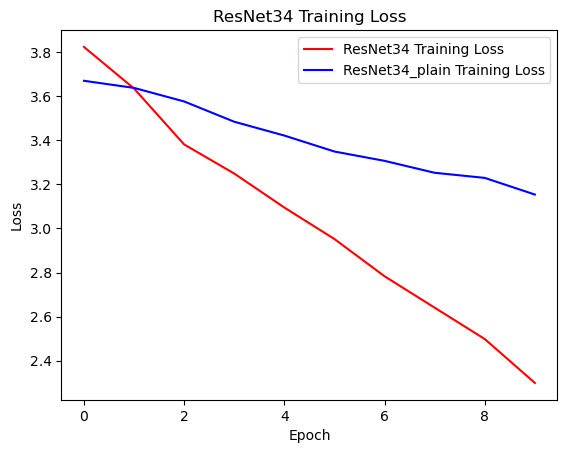

In [51]:
# train loss 비교
plot_train_loss(resnet34_results['train_loss'], resnet34_plain_results['train_loss'], "ResNet34")

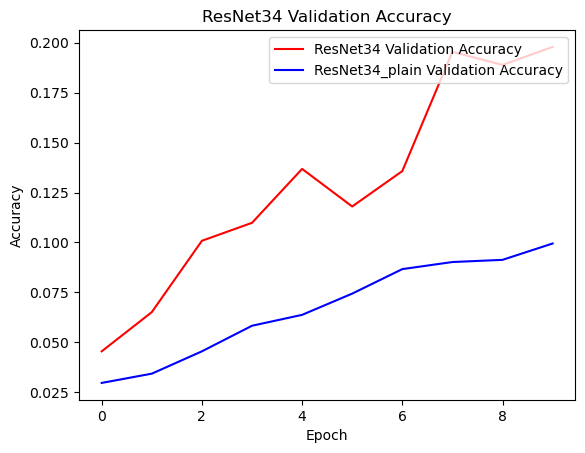

In [52]:
# validation accuracy 비교
plot_val_acc(resnet34_results['val_acc'], resnet34_plain_results['val_acc'], "ResNet34")

#### ResNet50

##### ResNet50 with shortcut

In [53]:
# 결과 비교를 위한 성능 저장할 딕셔너리
resnet50_results = {'train_loss': [], 'val_acc': []}

In [54]:
VERSION_NUM = 50
use_shortcut = True
NUM_CLASSES = 37

In [55]:
resnet50 = build_resnet(VERSION_NUM, resnet_configs, use_shortcut, NUM_CLASSES).to(device)

모델: ResNet50, block 개수: [3, 4, 6, 3], 출력 데이터 클래스 수: 37


In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet50.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)

In [57]:
resnet50_results = train_val(resnet50, trainloader, testloader, criterion, optimizer, resnet50_results)

[Epoch: 1,   50th batch] loss: 4.162
Epoch 1, Train Accuracy: 2.58%
Epoch 1, Validation Accuracy: 2.86%
[Epoch: 2,   50th batch] loss: 3.873
Epoch 2, Train Accuracy: 4.48%
Epoch 2, Validation Accuracy: 6.08%
[Epoch: 3,   50th batch] loss: 3.739
Epoch 3, Train Accuracy: 5.19%
Epoch 3, Validation Accuracy: 3.03%
[Epoch: 4,   50th batch] loss: 3.639
Epoch 4, Train Accuracy: 6.39%
Epoch 4, Validation Accuracy: 6.79%
[Epoch: 5,   50th batch] loss: 3.491
Epoch 5, Train Accuracy: 8.91%
Epoch 5, Validation Accuracy: 7.82%
[Epoch: 6,   50th batch] loss: 3.346
Epoch 6, Train Accuracy: 10.43%
Epoch 6, Validation Accuracy: 10.77%
[Epoch: 7,   50th batch] loss: 3.224
Epoch 7, Train Accuracy: 12.66%
Epoch 7, Validation Accuracy: 12.16%
[Epoch: 8,   50th batch] loss: 3.102
Epoch 8, Train Accuracy: 14.97%
Epoch 8, Validation Accuracy: 13.52%
[Epoch: 9,   50th batch] loss: 2.949
Epoch 9, Train Accuracy: 18.64%
Epoch 9, Validation Accuracy: 17.03%
[Epoch: 10,   50th batch] loss: 2.863
Epoch 10, Train Ac

##### ResNet50_plain (without shortcut)

In [59]:
resnet50_plain_results = {'train_loss': [], 'val_acc': []}

In [60]:
VERSION_NUM = 50
use_shortcut = False
NUM_CLASSES = 37

In [61]:
resnet50_plain = build_resnet(VERSION_NUM, resnet_configs, use_shortcut, NUM_CLASSES).to(device)

모델: ResNet50_plain, block 개수: [3, 4, 6, 3], 출력 데이터 클래스 수: 37


In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet50_plain.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)

In [63]:
resnet50_plain_results = train_val(resnet50_plain, trainloader, testloader, criterion, optimizer, resnet50_plain_results)

[Epoch: 1,   50th batch] loss: 3.729
Epoch 1, Train Accuracy: 2.58%
Epoch 1, Validation Accuracy: 3.19%
[Epoch: 2,   50th batch] loss: 3.697
Epoch 2, Train Accuracy: 2.47%
Epoch 2, Validation Accuracy: 2.92%
[Epoch: 3,   50th batch] loss: 3.661
Epoch 3, Train Accuracy: 2.58%
Epoch 3, Validation Accuracy: 2.70%
[Epoch: 4,   50th batch] loss: 3.643
Epoch 4, Train Accuracy: 3.07%
Epoch 4, Validation Accuracy: 3.13%
[Epoch: 5,   50th batch] loss: 3.633
Epoch 5, Train Accuracy: 2.64%
Epoch 5, Validation Accuracy: 3.35%
[Epoch: 6,   50th batch] loss: 3.612
Epoch 6, Train Accuracy: 3.64%
Epoch 6, Validation Accuracy: 3.73%
[Epoch: 7,   50th batch] loss: 3.608
Epoch 7, Train Accuracy: 3.99%
Epoch 7, Validation Accuracy: 3.22%
[Epoch: 8,   50th batch] loss: 3.599
Epoch 8, Train Accuracy: 3.78%
Epoch 8, Validation Accuracy: 3.82%
[Epoch: 9,   50th batch] loss: 3.580
Epoch 9, Train Accuracy: 3.56%
Epoch 9, Validation Accuracy: 3.87%
[Epoch: 10,   50th batch] loss: 3.570
Epoch 10, Train Accuracy: 

##### ResNet50 vs ResNet50_plain

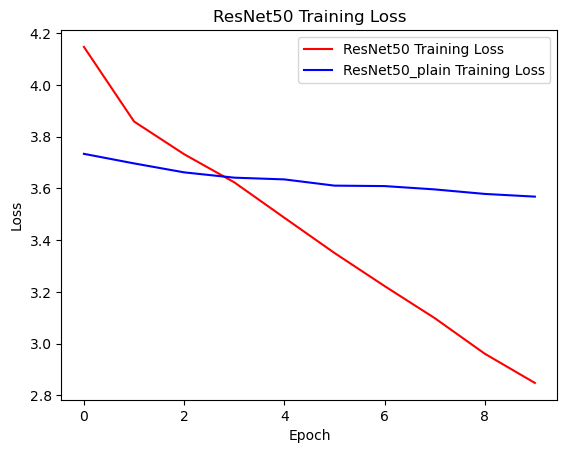

In [64]:
# train loss 비교
plot_train_loss(resnet50_results['train_loss'], resnet50_plain_results['train_loss'], "ResNet50")

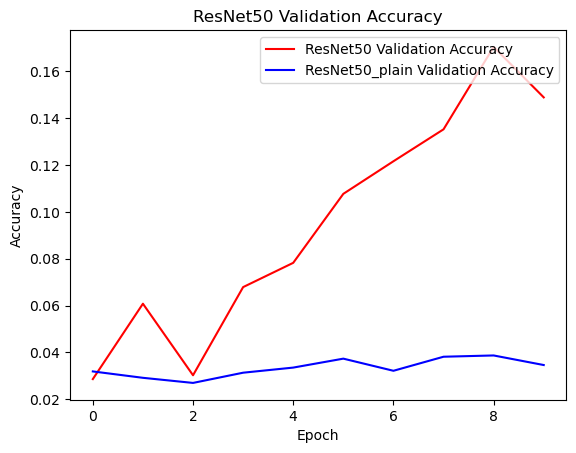

In [65]:
# validation accuracy 비교
plot_val_acc(resnet50_results['val_acc'], resnet50_plain_results['val_acc'], "ResNet50")

# 회고

- "블록 정의" -> "모델 확인" -> "데이터 준비" -> "모델 학습" -> "ablation study" 순서로 작업을 수행하였음.
- 모델의 구조적인 변화나 패턴(skip connection의 데이터 shape을 언제 맞춰줘야 하고, 어떻게 블록을 조작하는 부분)을 코드로 구현하는 과정을 더 고민해야 할 것 같다.
- 학습이 제대로 되려면 모델 구조와 함께 학습에 영향을 미치는 다른 많은 요인들까지 고려해야 하는 것 같다.
